In [36]:
.from collections import deque
graph = {
    'A': ['B', 'C'],
    'B': ['D', 'E'],
    'C': ['F'],
    'D': [],
    'E': ['G'],
    'F': [],
    'G': []
}
def bfs(graph, start, goal):
    queue = deque([start])
    visited = set()
    while queue:
        node = queue.popleft()
        if node not in visited:
            print(node, end=" ")
            visited.add(node)
            if node == goal:
                print("\nGoal Found")
                return
            for neighbour in graph[node]:
                if neighbour not in visited:
                    queue.append(neighbour)
    print("\nGoal Not Found")
bfs(graph, 'A', 'G')

A B C D E F G 
Goal Found


In [37]:
graph = {
    'A': ['B', 'C'],
    'B': ['D', 'E'],
    'C': ['F'],
    'D': [],
    'E': ['G'],
    'F': [],
    'G': []
}

visited = set()

def dfs(node, goal):
    if node not in visited:
        print(node, end=" ")
        visited.add(node)

        if node == goal:
            print("\nGoal Found")
            return True

        for neighbour in graph[node]:
            if dfs(neighbour, goal):
                return True

    return False

dfs('A', 'G')

A B D E G 
Goal Found


True

In [38]:
import heapq


def astar(graph, start, goal, heuristic):
    open_list = []
    heapq.heappush(open_list, (heuristic[start], 0, start))

    g_cost = {start: 0}
    parent = {start: None}

    while open_list:
        f_cost, current_g, current = heapq.heappop(open_list)

        # Skip outdated entries
        if current_g != g_cost[current]:
            continue

        if current == goal:
            path = []
            while current is not None:
                path.append(current)
                current = parent[current]
            return path[::-1], g_cost[goal]

        for neighbor, cost in graph.get(current, []):
            new_cost = current_g + cost

            if neighbor not in g_cost or new_cost < g_cost[neighbor]:
                g_cost[neighbor] = new_cost
                parent[neighbor] = current

                f_cost = new_cost + heuristic.get(neighbor, 0)
                heapq.heappush(open_list, (f_cost, new_cost, neighbor))

    return None, None


graph = {
    'A': [('B', 1), ('C', 4)],
    'B': [('D', 2), ('E', 5)],
    'C': [('F', 3)],
    'D': [('G', 1)],
    'E': [('G', 2)],
    'F': [('G', 2)],
    'G': []
}

heuristic = {
    'A': 7,
    'B': 6,
    'C': 4,
    'D': 2,
    'E': 2,
    'F': 1,
    'G': 0
}


path, cost = astar(graph, 'A', 'G', heuristic)

print("Path:", path)
print("Cost:", cost)


Path: ['A', 'B', 'D', 'G']
Cost: 4


In [39]:
import heapq

def memory_bounded_astar(graph, start, goal, heuristic, memory_limit=5):
    open_list = []
    heapq.heappush(open_list, (heuristic[start], 0, start, [start]))

    while open_list:
        f, g, node, path = heapq.heappop(open_list)

        if node == goal:
            return path

        for neighbor, cost in graph[node]:
            new_g = g + cost
            new_f = new_g + heuristic[neighbor]

            heapq.heappush(open_list,
                           (new_f, new_g, neighbor, path+[neighbor]))

        if len(open_list) > memory_limit:
            open_list.sort(reverse=True)
            open_list.pop(0)
            heapq.heapify(open_list)

    return None


print("Path:",
      memory_bounded_astar(graph, 'A', 'G', heuristic))

Path: ['A', 'B', 'D', 'G']


In [40]:
# Import Packages
import numpy as np
import pandas as pd

# Load the data from sklearn.datasets
from sklearn.datasets import load_iris
iris = load_iris()

# Separate features and target
X = iris.data # Select all features
Y = iris.target # Select target

# Ensure X is truly numeric (though pandas should infer correctly for this dataset)
X = X.astype(float)

# Split the data to train and test dataset.
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Support vector machine algorithm
from sklearn.svm import SVC
svn = SVC()
svn.fit(X_train, y_train)

# Predict from the test dataset
predictions = svn.predict(X_test)

# Calculate the accuracy
from sklearn.metrics import accuracy_score
accuracy_score(y_test, predictions)

# A detailed classification report
from sklearn.metrics import classification_report
print(classification_report(y_test, predictions))

X_new = np.array([[3, 2, 1, 0.2],
                  [4.9, 2.2, 3.8, 1.1],
                  [5.3, 2.5, 4.6, 1.9]])

#Prediction of the species from the input vector
prediction = svn.predict(X_new)
print("Prediction of Species: {}".format(prediction))
print()
print("Accuracy Score: ", accuracy_score(y_test, predictions))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

Prediction of Species: [0 1 2]

Accuracy Score:  1.0


In [41]:
# ============================================================
# STEP 1: Install pgmpy
# ============================================================

!pip install -q -U pgmpy


# ============================================================
# STEP 2: Import libraries
# ============================================================

import pandas as pd

from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import MaximumLikelihoodEstimator
from pgmpy.inference import VariableElimination


# ============================================================
# STEP 3: Load dataset
# ============================================================

data = pd.read_csv("cleaned_data.csv")

print("Original columns:")
print(data.columns.tolist())

print("\nFirst 5 rows:")
print(data.head())


# ============================================================
# STEP 4: Select required columns
# ============================================================

selected_columns = [
    "Fever",
    "Dry-Cough",
    "Difficulty-in-Breathing",
    "Tiredness",
    "Contact_Yes",
    "Severity_None"
]

missing_columns = [
    col for col in selected_columns
    if col not in data.columns
]

if missing_columns:
    raise ValueError(
        f"Missing columns: {missing_columns}"
    )

temp_data = data[selected_columns].copy()


# ============================================================
# STEP 5: Rename columns
# ============================================================

temp_data.rename(
    columns={
        "Dry-Cough": "Cough",
        "Difficulty-in-Breathing": "Breathing_Problem",
        "Tiredness": "Fatigue",
        "Contact_Yes": "Contact_with_COVID_Patient"
    },
    inplace=True
)


# ============================================================
# STEP 6: Convert data to numeric
# ============================================================

for column in temp_data.columns:

    temp_data[column] = pd.to_numeric(
        temp_data[column],
        errors="coerce"
    )


# Remove missing values
temp_data.dropna(inplace=True)

# Convert to integer
temp_data = temp_data.astype(int)


# ============================================================
# STEP 7: Create Corona_Positive
# ============================================================

temp_data["Corona_Positive"] = (
    1 - temp_data["Severity_None"]
)


# Remove Severity_None
temp_data.drop(
    columns=["Severity_None"],
    inplace=True
)


# ============================================================
# STEP 8: Display processed data
# ============================================================

print("\nProcessed columns:")
print(temp_data.columns.tolist())

print("\nProcessed data:")
print(temp_data.head())

print("\nDataset shape:")
print(temp_data.shape)


# ============================================================
# STEP 9: Define Bayesian Network
# ============================================================

model = DiscreteBayesianNetwork([
    ("Fever", "Corona_Positive"),
    ("Cough", "Corona_Positive"),
    ("Breathing_Problem", "Corona_Positive"),
    ("Fatigue", "Corona_Positive"),
    ("Contact_with_COVID_Patient",
     "Corona_Positive")
])


# ============================================================
# STEP 10: Learn CPDs
# ============================================================

# Omitting the manual estimator argument as model.fit automatically defaults
# to initializing and using the MaximumLikelihoodEstimator.
model.fit(
    temp_data
)


# ============================================================
# STEP 11: Check model
# ============================================================

print("\nModel valid:")
print(model.check_model())


# ============================================================
# STEP 12: Display CPDs
# ============================================================

print("\n" + "=" * 60)
print("LEARNED CONDITIONAL PROBABILITY DISTRIBUTIONS")
print("=" * 60)

for cpd in model.get_cpds():

    print("\nCPD of:", cpd.variable)
    print(cpd)


# ============================================================
# STEP 13: Initialize inference
# ============================================================

inference = VariableElimination(model)


# ============================================================
# STEP 14: Patient evidence
# ============================================================

evidence = {
    "Fever": 1,
    "Cough": 1,
    "Breathing_Problem": 1,
    "Fatigue": 1,
    "Contact_with_COVID_Patient": 1
}


print("\n" + "=" * 60)
print("PATIENT EVIDENCE")
print("=" * 60)

for key, value in evidence.items():
    print(f"{key}: {value}")


# ============================================================
# STEP 15: Bayesian inference
# ============================================================

result = inference.query(
    variables=["Corona_Positive"],
    evidence=evidence
)


# ============================================================
# STEP 16: Display inference result
# ============================================================

print("\n" + "=" * 60)
print("DIAGNOSIS RESULT")
print("=" * 60)

print(result)


# ============================================================
# STEP 17: Get probabilities
# ============================================================

print("\nProbability values:")
print(result.values)


# pgmpy normally stores states as 0 and 1
probability_negative = result.values[0]
probability_positive = result.values[1]


print(
    f"\nProbability of Corona Negative: "
    f"{probability_negative:.4f}"
)

print(
    f"Probability of Corona Positive: "
    f"{probability_positive:.4f}"
)


# ============================================================
# STEP 18: Final prediction
# ============================================================

if probability_positive > probability_negative:

    print("\nFinal Prediction: Corona Positive")

else:

    print("\nFinal Prediction: Corona Negative")

Original columns:
['Fever', 'Dry-Cough', 'Difficulty-in-Breathing', 'Tiredness', 'Contact_Yes', 'Severity_None']

First 5 rows:
   Fever  Dry-Cough  Difficulty-in-Breathing  Tiredness  Contact_Yes  \
0      1          1                        1          1            1   
1      1          1                        0          1            1   
2      1          0                        1          1            1   
3      0          1                        0          1            1   
4      1          1                        1          0            1   

   Severity_None  
0              0  
1              0  
2              0  
3              0  
4              0  

Processed columns:
['Fever', 'Cough', 'Breathing_Problem', 'Fatigue', 'Contact_with_COVID_Patient', 'Corona_Positive']

Processed data:
   Fever  Cough  Breathing_Problem  Fatigue  Contact_with_COVID_Patient  \
0      1      1                  1        1                           1   
1      1      1                  0    

In [42]:
import numpy as np
import pandas as pd
import math

# Load dataset
data = pd.read_csv('/content/IDE3 DATASET.csv')

# Features = all columns except target
features = [feat for feat in data.columns if feat != "answer"]


# ---------------------------------------------------------
# Node class
# ---------------------------------------------------------
class Node:
    def __init__(self):
        self.children = []
        self.value = ""
        self.isLeaf = False
        self.pred = ""


# ---------------------------------------------------------
# Entropy
# ---------------------------------------------------------
def entropy(examples):
    if len(examples) == 0:
        return 0

    counts = examples["answer"].value_counts()

    entropy_value = 0

    for count in counts:
        probability = count / len(examples)

        if probability > 0:
            entropy_value -= probability * math.log2(probability)

    return entropy_value


# ---------------------------------------------------------
# Information Gain
# ---------------------------------------------------------
def info_gain(examples, attr):

    total_entropy = entropy(examples)

    weighted_entropy = 0

    for value in examples[attr].unique():

        subset = examples[examples[attr] == value]

        weighted_entropy += (
            len(subset) / len(examples)
        ) * entropy(subset)

    return total_entropy - weighted_entropy


# ---------------------------------------------------------
# ID3 Algorithm
# ---------------------------------------------------------
def ID3(examples, attrs):

    # If all examples have the same answer
    if len(examples["answer"].unique()) == 1:

        leaf = Node()
        leaf.isLeaf = True
        leaf.pred = examples["answer"].iloc[0]

        return leaf


    # If no attributes remain
    if len(attrs) == 0:

        leaf = Node()
        leaf.isLeaf = True

        # Majority class
        leaf.pred = examples["answer"].mode()[0]

        return leaf


    # Find attribute with maximum information gain
    gains = {
        attr: info_gain(examples, attr)
        for attr in attrs
    }

    max_feat = max(gains, key=gains.get)

    root = Node()
    root.value = max_feat

    print(
        f"Selected attribute: {max_feat}, "
        f"Information Gain: {gains[max_feat]:.4f}"
    )


    # Create branches
    for value in examples[max_feat].unique():

        subset = examples[
            examples[max_feat] == value
        ]

        branch = Node()
        branch.value = value

        # Pure subset
        if entropy(subset) == 0:

            branch.isLeaf = True
            branch.pred = subset["answer"].iloc[0]

        else:

            remaining_attrs = attrs.copy()
            remaining_attrs.remove(max_feat)

            child = ID3(
                subset,
                remaining_attrs
            )

            branch.children.append(child)

        root.children.append(branch)

    return root


# ---------------------------------------------------------
# Print Decision Tree
# ---------------------------------------------------------
def printTree(root, depth=0):

    print(
        "\t" * depth +
        str(root.value),
        end=""
    )

    if root.isLeaf:
        print(" ->", root.pred)
        return

    print()

    for child in root.children:

        print(
            "\t" * (depth + 1) +
            str(child.value),
            end=""
        )

        if child.isLeaf:
            print(" ->", child.pred)

        else:
            print()

            if child.children:
                printTree(
                    child.children[0],
                    depth + 2
                )


# ---------------------------------------------------------
# Classification
# ---------------------------------------------------------
def classify(root, new):

    # If current node is a leaf
    if root.isLeaf:
        return root.pred

    attribute = root.value

    # Check whether input contains required attribute
    if attribute not in new:
        return "Unknown"

    value = new[attribute]

    # Find matching branch
    for child in root.children:

        if child.value == value:

            if child.isLeaf:
                return child.pred

            if child.children:
                return classify(
                    child.children[0],
                    new
                )

    # If value was not seen during training
    return "Unknown"


# ---------------------------------------------------------
# Build Decision Tree
# ---------------------------------------------------------
root = ID3(data, features)


# ---------------------------------------------------------
# Display Tree
# ---------------------------------------------------------
print("\nDecision Tree:")
printTree(root)


# ---------------------------------------------------------
# New Example
# ---------------------------------------------------------
new = {
    "outlook": "sunny",
    "temperature": "hot",
    "humidity": "normal",
    "wind": "strong"
}


# ---------------------------------------------------------
# Prediction
# ---------------------------------------------------------
prediction = classify(root, new)

print("\nNew Example:")
print(new)

print("\nPredicted Label:", prediction)


Selected attribute: outlook, Information Gain: 0.2467
Selected attribute: humidity, Information Gain: 0.9710
Selected attribute: wind, Information Gain: 0.9710

Decision Tree:
outlook
	sunny
		humidity
			high -> no
			normal -> yes
	overcast -> yes
	rainy
		wind
			weak -> yes
			strong -> no

New Example:
{'outlook': 'sunny', 'temperature': 'hot', 'humidity': 'normal', 'wind': 'strong'}

Predicted Label: yes


In [43]:
# Import libraries
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load dataset
iris = load_iris()
X = iris.data
y = iris.target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

# Create Random Forest model
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the model
rf.fit(X_train, y_train)

# Predict
y_pred = rf.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Accuracy: 1.0

Confusion Matrix
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



In [44]:
# Import libraries
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load dataset
iris = load_iris()
X = iris.data
y = iris.target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

# Create SVM model
svm = SVC(kernel='rbf', C=1.0, gamma='scale')

# Train the model
svm.fit(X_train, y_train)

# Predict
y_pred = svm.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Accuracy: 1.0

Confusion Matrix
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



IRIS DATASET
--------------------------------------------------
Number of samples : 150
Number of features: 4
Classes           : [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]


SAMPLE PREDICTIONS
---------------------------------------------------------------------------
Sample    Actual         Bagging        Boosting       Stacking       
---------------------------------------------------------------------------
1         setosa         setosa         setosa         setosa         
2         virginica      virginica      virginica      virginica      
3         versicolor     versicolor     versicolor     versicolor     
4         versicolor     versicolor     versicolor     versicolor     
5         setosa         setosa         setosa         setosa         
6         versicolor     versicolor     versicolor     versicolor     
7         setosa         setosa         setosa         setosa         
8         setosa         setosa         setosa         setosa   

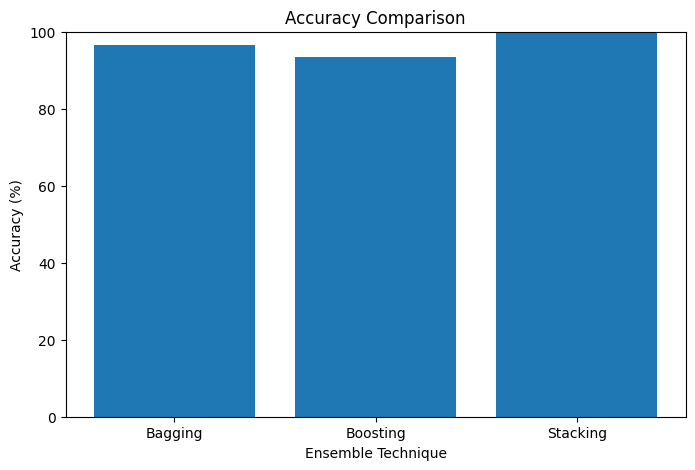

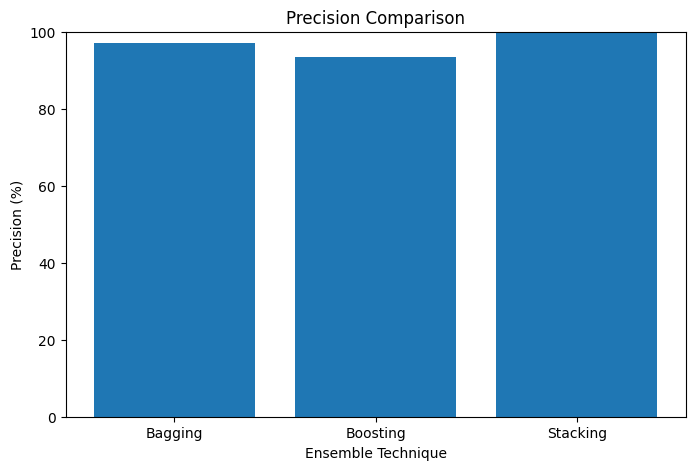

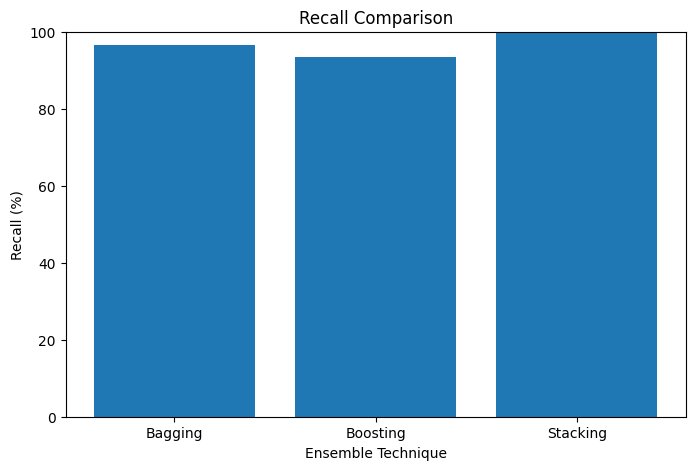

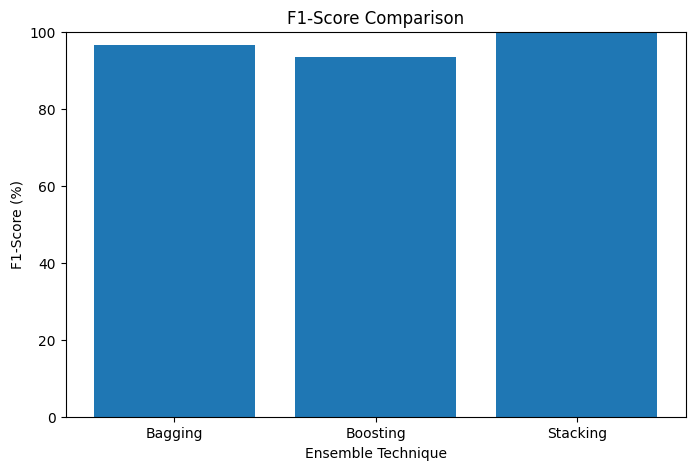

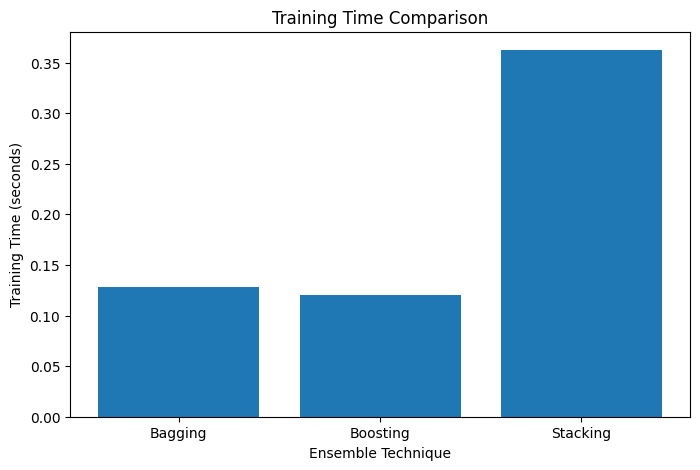

In [45]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    BaggingClassifier,
    AdaBoostClassifier,
    StackingClassifier
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

# FIX: import, not =
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)


# -------------------------------------------------------
# 1. LOAD DATASET
# -------------------------------------------------------

iris = load_iris()

X = iris.data
y = iris.target

class_names = iris.target_names

print("IRIS DATASET")
print("-" * 50)
print("Number of samples :", len(X))
print("Number of features:", X.shape[1])
print("Classes           :", list(class_names))


# -------------------------------------------------------
# 2. SPLIT DATASET
# -------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


# -------------------------------------------------------
# 3. BAGGING
# -------------------------------------------------------

bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(
        random_state=42
    ),
    n_estimators=5,
    random_state=42
)

start = time.time()

bagging.fit(X_train, y_train)

bagging_time = time.time() - start

bagging_pred = bagging.predict(X_test)


# -------------------------------------------------------
# 4. BOOSTING
# -------------------------------------------------------

boosting = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(
        max_depth=1,
        random_state=42
    ),
    n_estimators=5,
    random_state=42
)

start = time.time()

boosting.fit(X_train, y_train)

boosting_time = time.time() - start

boosting_pred = boosting.predict(X_test)


# -------------------------------------------------------
# 5. STACKING
# -------------------------------------------------------

base_models = [
    (
        "Decision Tree",
        DecisionTreeClassifier(
            max_depth=3,
            random_state=42
        )
    ),
    (
        "KNN",
        KNeighborsClassifier(
            n_neighbors=5
        )
    )
]

stacking = StackingClassifier(
    estimators=base_models,
    final_estimator=LogisticRegression(
        max_iter=1000
    )
)

start = time.time()

stacking.fit(X_train, y_train)

stacking_time = time.time() - start

stacking_pred = stacking.predict(X_test)


# -------------------------------------------------------
# 6. SAMPLE PREDICTIONS
# -------------------------------------------------------

print("\n\nSAMPLE PREDICTIONS")
print("-" * 75)

print(
    f"{'Sample':<10}"
    f"{'Actual':<15}"
    f"{'Bagging':<15}"
    f"{'Boosting':<15}"
    f"{'Stacking':<15}"
)

print("-" * 75)

for i in range(min(10, len(X_test))):

    actual = class_names[y_test[i]]
    bag = class_names[bagging_pred[i]]
    boost = class_names[boosting_pred[i]]
    stack = class_names[stacking_pred[i]]

    print(
        f"{i + 1:<10}"
        f"{actual:<15}"
        f"{bag:<15}"
        f"{boost:<15}"
        f"{stack:<15}"
    )


# -------------------------------------------------------
# 7. BAGGING VOTING DECISION
# -------------------------------------------------------

print("\n\nBAGGING VOTING DECISION")
print("-" * 50)

sample = X_test[0].reshape(1, -1)

tree_predictions = []

for tree in bagging.estimators_:

    prediction = tree.predict(sample)[0]

    tree_predictions.append(prediction)

    print(
        "Decision Tree ->",
        class_names[prediction]
    )


# Majority voting
votes = np.bincount(
    tree_predictions,
    minlength=len(class_names)
)

final_vote = np.argmax(votes)

print("\nVotes:")

for i, count in enumerate(votes):

    print(
        class_names[i],
        "->",
        count,
        "votes"
    )

print(
    "\nFinal Bagging Prediction:",
    class_names[final_vote]
)


# -------------------------------------------------------
# 8. BOOSTING DECISION
# -------------------------------------------------------

print("\n\nBOOSTING DECISION")
print("-" * 50)

boost_sample = X_test[0].reshape(1, -1)

boost_predictions = []

for estimator in boosting.estimators_:

    prediction = estimator.predict(
        boost_sample
    )[0]

    boost_predictions.append(prediction)


print("Weak Learner Predictions:")

for i, prediction in enumerate(
    boost_predictions
):

    print(
        "Learner",
        i + 1,
        "->",
        class_names[prediction]
    )


# Weighted probabilities
probability = boosting.predict_proba(
    boost_sample
)[0]

print("\nWeighted Class Probabilities:")

for i, value in enumerate(probability):

    print(
        class_names[i],
        "->",
        round(value, 4)
    )


boost_final = boosting.predict(
    boost_sample
)[0]

print(
    "\nFinal Boosting Prediction:",
    class_names[boost_final]
)


# -------------------------------------------------------
# 9. STACKING DECISION
# -------------------------------------------------------

print("\n\nSTACKING DECISION")
print("-" * 50)

stack_sample = X_test[0].reshape(1, -1)


dt_prediction = stacking.named_estimators_[
    "Decision Tree"
].predict(stack_sample)[0]

knn_prediction = stacking.named_estimators_[
    "KNN"
].predict(stack_sample)[0]

stack_prediction = stacking.predict(
    stack_sample
)[0]


print(
    "Decision Tree ->",
    class_names[dt_prediction]
)

print(
    "KNN            ->",
    class_names[knn_prediction]
)

print(
    "Meta Learner   ->",
    class_names[stack_prediction]
)

print(
    "\nFinal Stacking Prediction:",
    class_names[stack_prediction]
)


# -------------------------------------------------------
# 10. PERFORMANCE METRICS
# -------------------------------------------------------

models = {
    "Bagging": (
        bagging_pred,
        bagging_time
    ),
    "Boosting": (
        boosting_pred,
        boosting_time
    ),
    "Stacking": (
        stacking_pred,
        stacking_time
    )
}

results = []

for name, (prediction, train_time) in models.items():

    acc = accuracy_score(
        y_test,
        prediction
    )

    precision = precision_score(
        y_test,
        prediction,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_test,
        prediction,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        prediction,
        average="weighted",
        zero_division=0
    )

    results.append([
        name,
        acc * 100,
        precision * 100,
        recall * 100,
        f1 * 100,
        train_time
    ])


# -------------------------------------------------------
# 11. COMPARISON TABLE
# -------------------------------------------------------

results_df = pd.DataFrame(
    results,
    columns=[
        "Technique",
        "Accuracy (%)",
        "Precision (%)",
        "Recall (%)",
        "F1-Score (%)",
        "Training Time (sec)"
    ]
)

print("\n\nPARAMETRIC COMPARISON")
print("=" * 85)

print(
    results_df.to_string(
        index=False,
        formatters={
            "Accuracy (%)": "{:.2f}".format,
            "Precision (%)": "{:.2f}".format,
            "Recall (%)": "{:.2f}".format,
            "F1-Score (%)": "{:.2f}".format,
            "Training Time (sec)": "{:.4f}".format
        }
    )
)


# -------------------------------------------------------
# 12. VISUALIZATION
# -------------------------------------------------------

techniques = results_df["Technique"]


# Accuracy
plt.figure(figsize=(8, 5))

plt.bar(
    techniques,
    results_df["Accuracy (%)"]
)

plt.xlabel("Ensemble Technique")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy Comparison")
plt.ylim(0, 100)

plt.show()


# Precision
plt.figure(figsize=(8, 5))

plt.bar(
    techniques,
    results_df["Precision (%)"]
)

plt.xlabel("Ensemble Technique")
plt.ylabel("Precision (%)")
plt.title("Precision Comparison")
plt.ylim(0, 100)

plt.show()


# Recall
plt.figure(figsize=(8, 5))

plt.bar(
    techniques,
    results_df["Recall (%)"]
)

plt.xlabel("Ensemble Technique")
plt.ylabel("Recall (%)")
plt.title("Recall Comparison")
plt.ylim(0, 100)

plt.show()


# F1 Score
plt.figure(figsize=(8, 5))

plt.bar(
    techniques,
    results_df["F1-Score (%)"]
)

plt.xlabel("Ensemble Technique")
plt.ylabel("F1-Score (%)")
plt.title("F1-Score Comparison")
plt.ylim(0, 100)

plt.show()


# Training Time
plt.figure(figsize=(8, 5))

plt.bar(
    techniques,
    results_df["Training Time (sec)"]
)

plt.xlabel("Ensemble Technique")
plt.ylabel("Training Time (seconds)")
plt.title("Training Time Comparison")

plt.show()


First 5 records:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2

Dataset Shape:
(150, 4)

Standardized Data:
[[-0.90068117  1.01900435 -1.34022653 -1.3154443 ]
 [-1.14301691 -0.13197948 -1.34022653 -1.3154443 ]
 [-1.38535265  0.32841405 -1.39706395 -1.3154443 ]
 [-1.50652052  0.09821729 -1.2833891  -1.3154443 ]
 [-1.02184904  1.24920112 -1.34022653 -1.3154443 ]]


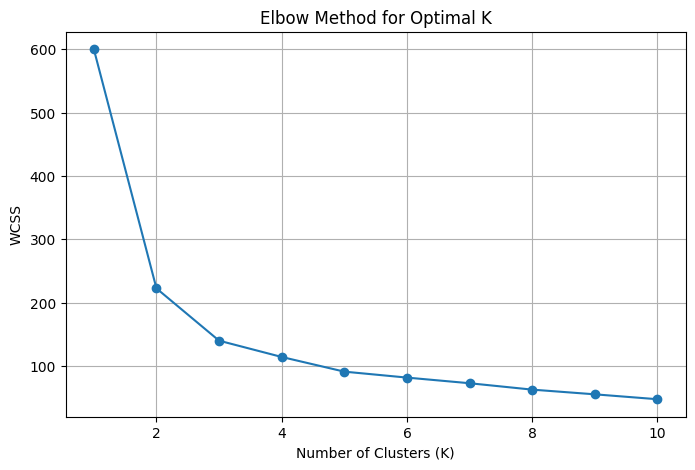


Cluster Assignments:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   
5                5.4               3.9                1.7               0.4   
6                4.6               3.4                1.4               0.3   
7                5.0               3.4                1.5               0.2   
8                4.4               2.9                1.4               0.2   
9                4.9               3.1                1.5               0.1   

   Cluster  
0        1  
1        1  
2        1  
3        1  
4        1  
5        1  
6        1  
7   

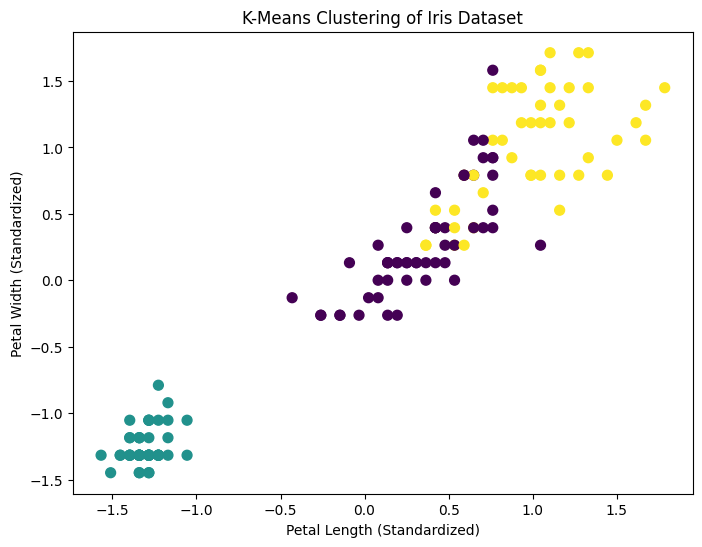


Actual Species vs Cluster:
   Actual Species  Cluster
0          setosa        1
1          setosa        1
2          setosa        1
3          setosa        1
4          setosa        1
5          setosa        1
6          setosa        1
7          setosa        1
8          setosa        1
9          setosa        1
10         setosa        1
11         setosa        1
12         setosa        1
13         setosa        1
14         setosa        1
15         setosa        1
16         setosa        1
17         setosa        1
18         setosa        1
19         setosa        1

Number of Samples in Each Cluster:
Cluster
0    53
1    50
2    47
Name: count, dtype: int64


In [46]:
# K-MEANS CLUSTERING USING IRIS DATASET

# Step 1: Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Step 2: Load the Iris dataset
iris = load_iris()

X = iris.data
y = iris.target

# Create a DataFrame
df = pd.DataFrame(X, columns=iris.feature_names)

print("First 5 records:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)
# Step 3: Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nStandardized Data:")
print(X_scaled[:5])
# Step 4: Elbow Method to determine the value of K
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method for Optimal K")
plt.grid()
plt.show()

48
# Step 5: Apply K-Means with K = 3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

clusters = kmeans.fit_predict(X_scaled)

# Add cluster labels to the DataFrame
df["Cluster"] = clusters

print("\nCluster Assignments:")
print(df.head(10))

# Step 6: Display cluster centers
print("\nCluster Centers:")
print(kmeans.cluster_centers_)

# Step 7: Calculate Silhouette Score
sil_score = silhouette_score(X_scaled, clusters)

print("\nSilhouette Score:", sil_score)
# Step 8: Visualize the clusters
plt.figure(figsize=(8, 6))

plt.scatter(
    X_scaled[:, 2],
    X_scaled[:, 3],
    c=clusters,
    s=50
)
plt.xlabel("Petal Length (Standardized)")
plt.ylabel("Petal Width (Standardized)")
plt.title("K-Means Clustering of Iris Dataset")

plt.show()
# Step 9: Compare clusters with actual species
comparison = pd.DataFrame({
    "Actual Species": iris.target_names[y],
    "Cluster": clusters
})

print("\nActual Species vs Cluster:")
print(comparison.head(20))
# Step 10: Display cluster-wise count
print("\nNumber of Samples in Each Cluster:")
print(df["Cluster"].value_counts().sort_index())

Original Complete Data:
   Smoking  Lung_Cancer
0        0            0
1        1            0
2        1            0
3        1            0
4        0            0
5        0            0
6        0            0
7        1            0
8        1            1
9        1            0

Data with Missing Values:
   Smoking  Lung_Cancer
0        0          NaN
1        1          NaN
2        1          0.0
3        1          0.0
4        0          0.0
5        0          NaN
6        0          0.0
7        1          NaN
8        1          1.0
9        1          NaN

Number of missing Lung Cancer values: 200

EM converged at iteration: 12

FINAL EM PARAMETERS
P(Lung Cancer=1 | Non-Smoker) = 0.0
P(Lung Cancer=1 | Smoker)     = 0.0861

True parameters used to generate data:
P(L=1 | S=0) = 0.01
P(L=1 | S=1) = 0.10

Accuracy of recovered missing values: 93.0 %


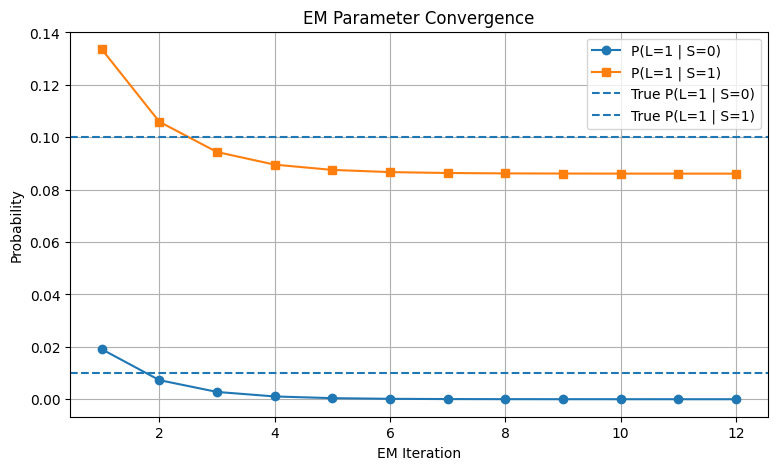

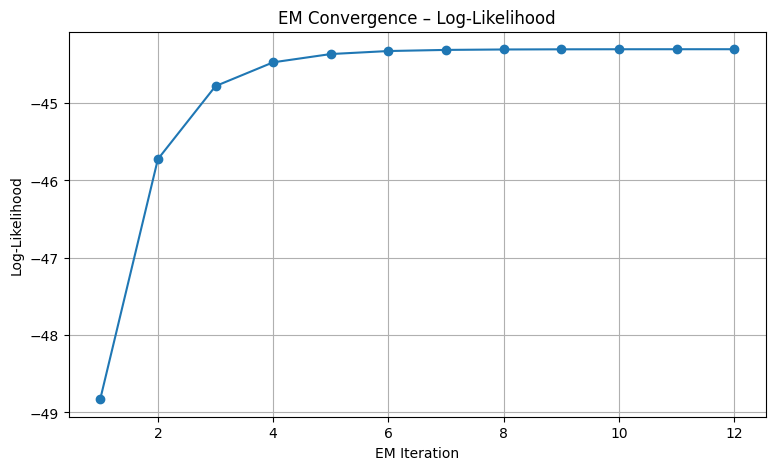


First 30 recovered missing observations:
    Smoking  Actual_Lung_Cancer  EM_Estimated_Lung_Cancer
0         0                   0                       0.0
1         1                   0                       0.0
2         1                   0                       0.0
3         1                   0                       0.0
4         0                   0                       0.0
5         1                   0                       0.0
6         1                   0                       0.0
7         1                   0                       0.0
8         1                   0                       0.0
9         0                   0                       0.0
10        0                   0                       0.0
11        1                   0                       0.0
12        1                   0                       0.0
13        1                   0                       0.0
14        1                   1                       0.0
15        0                   

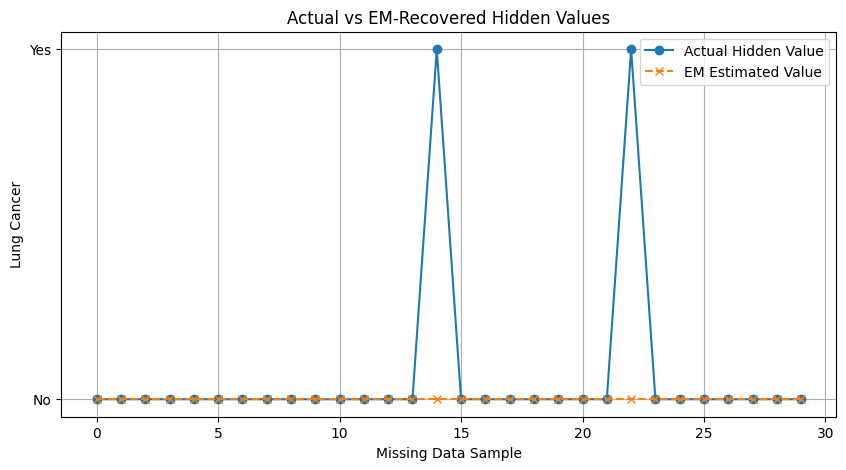

In [47]:
# ================================================================
# EM ALGORITHM FOR BAYESIAN NETWORKS
# Single-cell Google Colab implementation with visualization
# ================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

# ------------------------------------------------
# 1. CREATE A SIMPLE BAYESIAN NETWORK
# ------------------------------------------------
# Bayesian Network:
#
#       Smoking (S)
#          |
#          v
#    Lung Cancer (L)
#
# S = 0 : Non-Smoker
# S = 1 : Smoker
# L = 0 : No Lung Cancer
# L = 1 : Lung Cancer
#
# True probabilities used to generate data:
# P(L=1 | S=0) = 0.01
# P(L=1 | S=1) = 0.10

N = 500

S = np.random.binomial(1, 0.5, N)

L = np.array([
    np.random.binomial(1, 0.10 if s == 1 else 0.01)
    for s in S
])

complete_data = pd.DataFrame({
    "Smoking": S,
    "Lung_Cancer": L
})

# ------------------------------------------------
# 2. REMOVE SOME LUNG CANCER VALUES
# ------------------------------------------------
# These become the hidden/missing values that EM
# has to estimate.

incomplete_data = complete_data.copy()

missing_index = np.random.choice(
    N, size=int(0.40 * N), replace=False
)

incomplete_data.loc[missing_index, "Lung_Cancer"] = np.nan

print("Original Complete Data:")
print(complete_data.head(10))

print("\nData with Missing Values:")
print(incomplete_data.head(10))

print("\nNumber of missing Lung Cancer values:",
      incomplete_data["Lung_Cancer"].isna().sum())

# ------------------------------------------------
# 3. INITIALIZE EM PARAMETERS
# ------------------------------------------------
# Initial guesses are deliberately different
# from the true values.

p_L_given_S0 = 0.05
p_L_given_S1 = 0.20

max_iterations = 30
tolerance = 0.00001

likelihood_history = []

parameter_history = []

# ------------------------------------------------
# 4. EXPECTATION-MAXIMIZATION
# ------------------------------------------------

for iteration in range(max_iterations):

    # ============================================================
    # E-STEP
    # ============================================================
    # Estimate probability of Lung Cancer for missing observations.

    expected_L = incomplete_data["Lung_Cancer"].copy()

    for i in missing_index:

        if incomplete_data.loc[i, "Smoking"] == 0:
            expected_L.loc[i] = p_L_given_S0
        else:
            expected_L.loc[i] = p_L_given_S1

    # ============================================================
    # M-STEP
    # ============================================================
    # Update P(L=1 | S=0) and P(L=1 | S=1)

    smokers = incomplete_data["Smoking"] == 1
    nonsmokers = incomplete_data["Smoking"] == 0

    new_p_L_given_S0 = expected_L[nonsmokers].mean()
    new_p_L_given_S1 = expected_L[smokers].mean()

    # ============================================================
    # LOG-LIKELIHOOD
    # ============================================================
    log_likelihood = 0

    for i in range(N):

        s = incomplete_data.loc[i, "Smoking"]

        # Observed value
        if not pd.isna(incomplete_data.loc[i, "Lung_Cancer"]):

            l = incomplete_data.loc[i, "Lung_Cancer"]

            p = (
                new_p_L_given_S1 if s == 1
                else new_p_L_given_S0
            )

            if l == 1:
                log_likelihood += np.log(p + 1e-10)
            else:
                log_likelihood += np.log(1 - p + 1e-10)

        # Missing value
        else:

            p = (
                new_p_L_given_S1 if s == 1
                else new_p_L_given_S0
            )

            # Missing variable is marginalized:
            # P(L=0) + P(L=1) = 1
            log_likelihood += np.log(1.0)

    likelihood_history.append(log_likelihood)

    parameter_history.append(
        [new_p_L_given_S0, new_p_L_given_S1]
    )

    # Check convergence
    change = max(
        abs(new_p_L_given_S0 - p_L_given_S0),
        abs(new_p_L_given_S1 - p_L_given_S1)
    )

    p_L_given_S0 = new_p_L_given_S0
    p_L_given_S1 = new_p_L_given_S1

    if change < tolerance:
        print("\nEM converged at iteration:", iteration + 1)
        break

# ------------------------------------------------
# 5. FINAL PARAMETER ESTIMATION
# ------------------------------------------------

print("\n==========================================")
print("FINAL EM PARAMETERS")
print("==========================================")

print(
    "P(Lung Cancer=1 | Non-Smoker) =",
    round(p_L_given_S0, 4)
)

print(
    "P(Lung Cancer=1 | Smoker)     =",
    round(p_L_given_S1, 4)
)

print("\nTrue parameters used to generate data:")
print("P(L=1 | S=0) = 0.01")
print("P(L=1 | S=1) = 0.10")

# ------------------------------------------------
# 6. ESTIMATE THE MISSING VALUES
# ------------------------------------------------

estimated_missing = incomplete_data.copy()

for i in missing_index:

    if incomplete_data.loc[i, "Smoking"] == 0:
        probability = p_L_given_S0
    else:
        probability = p_L_given_S1

    # Convert probability into predicted class
    estimated_missing.loc[i, "Lung_Cancer"] = (
        1 if probability >= 0.5 else 0
    )

# ------------------------------------------------
# 7. CALCULATE RECOVERY ACCURACY
# ------------------------------------------------

actual = complete_data.loc[
    missing_index, "Lung_Cancer"
]

predicted = estimated_missing.loc[
    missing_index, "Lung_Cancer"
]

accuracy = np.mean(actual.values == predicted.values)

print("\nAccuracy of recovered missing values:",
      round(accuracy * 100, 2), "%")

# ================================================================
# 8. VISUALIZATION 1 – EM CONVERGENCE
# ================================================================

parameter_history = np.array(parameter_history)

plt.figure(figsize=(9,5))

plt.plot(
    range(1, len(parameter_history)+1),
    parameter_history[:,0],
    marker='o',
    label="P(L=1 | S=0)"
)

plt.plot(
    range(1, len(parameter_history)+1),
    parameter_history[:,1],
    marker='s',
    label="P(L=1 | S=1)"
)

plt.axhline(
    0.01,
    linestyle='--',
    label="True P(L=1 | S=0)"
)

plt.axhline(
    0.10,
    linestyle='--',
    label="True P(L=1 | S=1)"
)

plt.xlabel("EM Iteration")
plt.ylabel("Probability")
plt.title("EM Parameter Convergence")
plt.legend()
plt.grid(True)
plt.show()

# ================================================================
# 9. VISUALIZATION 2 – LOG-LIKELIHOOD
# ================================================================

plt.figure(figsize=(9,5))

plt.plot(
    range(1, len(likelihood_history)+1),
    likelihood_history,
    marker='o'
)

plt.xlabel("EM Iteration")
plt.ylabel("Log-Likelihood")
plt.title("EM Convergence – Log-Likelihood")
plt.grid(True)
plt.show()

# ================================================================
# 10. VISUALIZATION 3 – MISSING VS RECOVERED DATA
# ================================================================

# Display first 30 missing observations

comparison = pd.DataFrame({
    "Smoking":
        complete_data.loc[missing_index, "Smoking"].values,

    "Actual_Lung_Cancer":
        complete_data.loc[missing_index, "Lung_Cancer"].values,

    "EM_Estimated_Lung_Cancer":
        estimated_missing.loc[missing_index, "Lung_Cancer"].values
})

print("\nFirst 30 recovered missing observations:")
print(comparison.head(30))

plt.figure(figsize=(10,5))

plt.plot(
    comparison["Actual_Lung_Cancer"].values[:30],
    'o-',
    label="Actual Hidden Value"
)

plt.plot(
    comparison["EM_Estimated_Lung_Cancer"].values[:30],
    'x--',
    label="EM Estimated Value"
)

plt.xlabel("Missing Data Sample")
plt.ylabel("Lung Cancer")
plt.title("Actual vs EM-Recovered Hidden Values")
plt.yticks([0,1], ["No", "Yes"])
plt.legend()
plt.grid(True)
plt.show()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


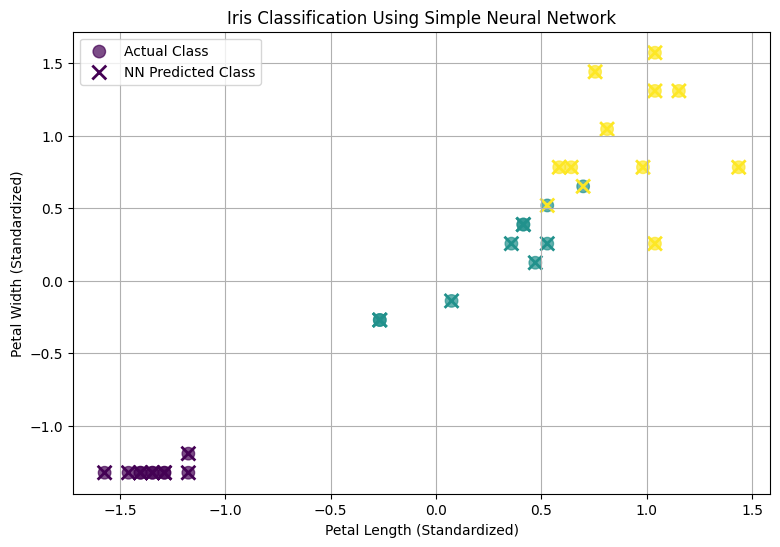

In [48]:
# ============================================================
# SIMPLE NEURAL NETWORK – IRIS CLASSIFICATION VISUALIZATION
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# ------------------------------------------------------------
# 1. LOAD IRIS DATASET
# ------------------------------------------------------------
iris = load_iris()
X = iris.data
y = iris.target
# ------------------------------------------------------------
# 2. TRAIN-TEST SPLIT
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
# ------------------------------------------------------------
# 3. STANDARDIZE FEATURES
# ------------------------------------------------------------

scaler = StandardScaler()

63
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ------------------------------------------------------------
# 4. BUILD SIMPLE NEURAL NETWORK
# ------------------------------------------------------------

model = Sequential([
    Dense(8, activation='relu', input_shape=(4,)),
    Dense(8, activation='relu'),
    Dense(3, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy'
)

# ------------------------------------------------------------
# 5. TRAIN THE NETWORK
# ------------------------------------------------------------

model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=8,
    verbose=0
)

# ------------------------------------------------------------
# 6. PREDICT TEST DATA
# ------------------------------------------------------------

probabilities = model.predict(X_test, verbose=0)

y_pred = np.argmax(probabilities, axis=1)

# ------------------------------------------------------------
# 7. VISUALIZE CLASSIFICATION
# ------------------------------------------------------------
# Use Petal Length and Petal Width for visualization.
# The neural network still uses all four features.

plt.figure(figsize=(9, 6))

# Actual classes
plt.scatter(
    X_test[:, 2],
    X_test[:, 3],
    c=y_test,
    marker='o',
    s=80,
    alpha=0.7,
    label='Actual Class'
)
64

# Predicted classes
plt.scatter(
    X_test[:, 2],
    X_test[:, 3],
    c=y_pred,
    marker='x',
    s=100,
    linewidths=2,
    label='NN Predicted Class'
)

plt.xlabel("Petal Length (Standardized)")
plt.ylabel("Petal Width (Standardized)")

plt.title("Iris Classification Using Simple Neural Network")

plt.legend()

plt.grid(True)

plt.show()